# Introduction to the ODL tomography interface
In this lab we will perform our first tomographic reconstruction. The problem involves reconstructing a given 2D image from its sinogram, obtained with the forward operator given by parallel ray transforms across all angles. 

1. First, define the function space. Our function will be defined in the space $L_2([-2, 2]^2)$ over the real numbers. Use the function ``odl.uniform_discr`` to create a discretized space of real functions in two variables, i.e., images, and pass ``dtype='float32'``, which the ASTRA backend requires in ODL 1.0.

2. Define the unit disk indicator function (i.e., $x^2 + y^2 \leq 1$) with an appropriate Python function and turn it into an element of the space. This can be a bit tricky since you cannot use ``if`` in your function, but it may help to know that ``True`` equals 1 in Python.

3. Use the method ``show`` to visualize the function. Since our space is two-dimensional, ``show`` will interpret a space element as grey-scale image. 

4. Next we set up the tomography geometry. For a parallel-beam geometry, use the function [odl.applications.tomo.parallel_beam_geometry](https://odl.readthedocs.io/generated/odl.applications.tomo.geometry.parallel.parallel_beam_geometry.html), which automatically sets the angles and parallel beam distances in order to fully sample the discretized function.

5. Now we can form the (discretized) forward operator (the measurement matrix) by calling [odl.applications.tomo.RayTransform](https://odl.readthedocs.io/generated/odl.applications.tomo.operators.ray_trafo.RayTransform.html) with the space and the geometry.

6. Obtain a sinogram by applying the forward operator to the space element and display it with the ``show`` method. Note that this sinogram is analytically tractable in the corresponding undiscretized/infinite-dimensional problem, so you should verify that the numerical sinogram has the correct shape.

7. Add some [Gaussian noise](https://odl.readthedocs.io/generated/odl.core.phantom.noise.white_noise.html) to your sinogram (which lives in the space ``Operator.range``) and compare with the original sinogram.

8. Next, use the adjoint of the operator to backproject the noisy sinogram, which should be accessible with ``Operator.adjoint``. Compare with the original image and try to figure out why the backprojection looks the way it does.

9. A filtered backprojection can be obtained using [odl.applications.tomo.fbp_op](https://odl.readthedocs.io/generated/odl.applications.tomo.analytic.filtered_back_projection.fbp_op.html). You should test different filter types by passing ``filter_type``. Compare with the original image.

10. Play around with this example by changing the number of angles, that is, by setting the ``num_angles``-parameter when defining the geometry, or by using a different geometry, or by using a different image like the [Shepp–Logan phantom](https://odl.readthedocs.io/generated/odl.core.phantom.transmission.shepp_logan.html), etc. Observe the characteristic shapes of the artifacts.

In [4]:
import odl
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. Create L2 space
l2 = odl.uniform_discr((-2, -2), (2, 2), (128, 128), dtype='float32')

In [6]:
# 2. Create disk indicator function
def unit_disk_indicator(x):
    return x[0]**2 + x[1]**2 <= 1

unit_disk_indicator_elements = l2.element(unit_disk_indicator)

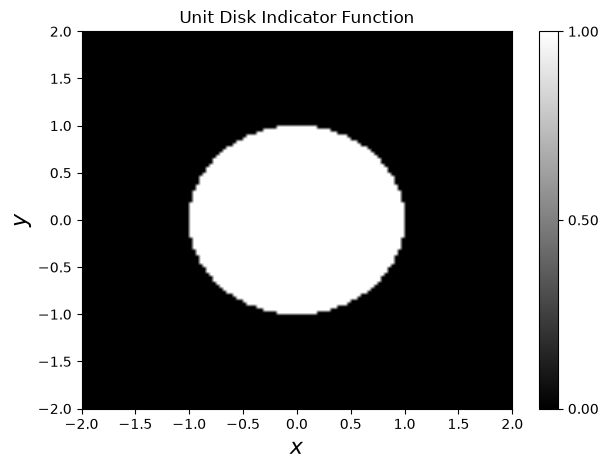

<Figure size 640x480 with 0 Axes>

In [7]:
# 3. Show the function
fig = unit_disk_indicator_elements.show(title='Unit Disk Indicator Function', cmap='gray')

In [8]:
#4. Create tomography geometry
tomo_geometry = odl.applications.tomo.parallel_beam_geometry(l2)

In [9]:
#5. Create ray transform (discretized forward operator)
ray_transform = odl.applications.tomo.RayTransform(l2, tomo_geometry)

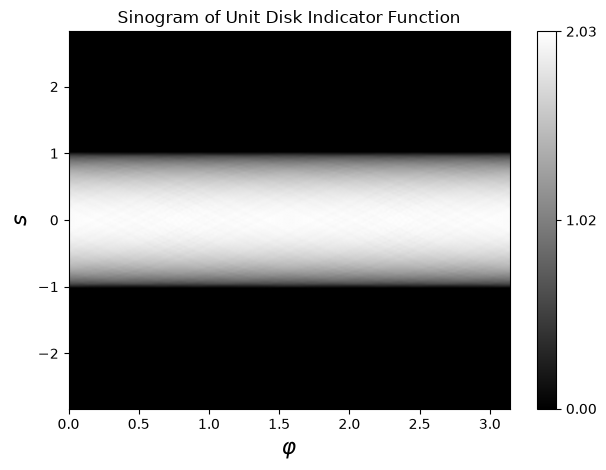

<Figure size 640x480 with 0 Axes>

In [10]:
# 6. Create sinogram
ray_transform_elements = ray_transform(unit_disk_indicator_elements)
fig = ray_transform_elements.show(title='Sinogram of Unit Disk Indicator Function', cmap='gray')

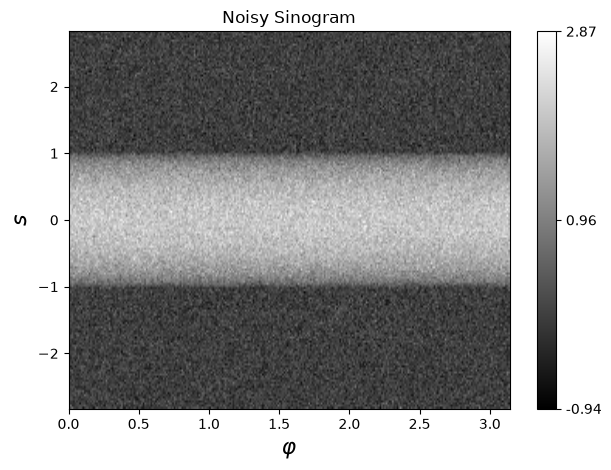

<Figure size 640x480 with 0 Axes>

In [21]:
#7 Add Gaussian noise to sinogram
noisy_sinogram = ray_transform_elements + odl.phantom.white_noise(ray_transform.range, stddev=0.25)
fig = noisy_sinogram.show(title='Noisy Sinogram', cmap='gray')

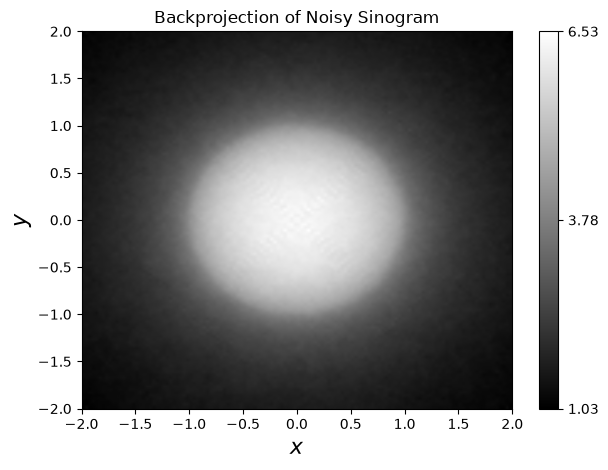

<Figure size 640x480 with 0 Axes>

In [22]:
#8 Backprojection of noisy sinogram using adjoint
adjoint = ray_transform.adjoint(noisy_sinogram)
fig = adjoint.show(title='Backprojection of Noisy Sinogram', cmap='gray')

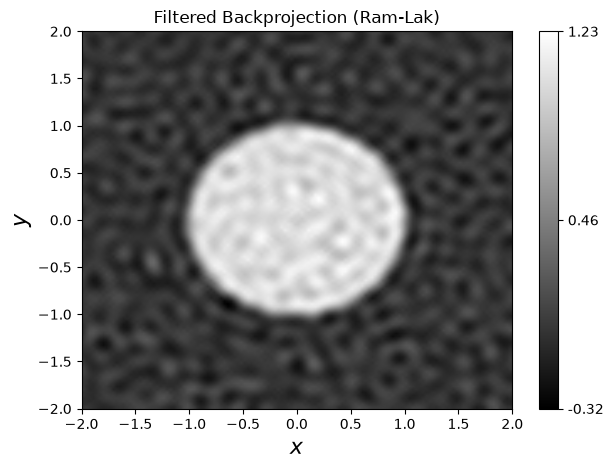

<Figure size 640x480 with 0 Axes>

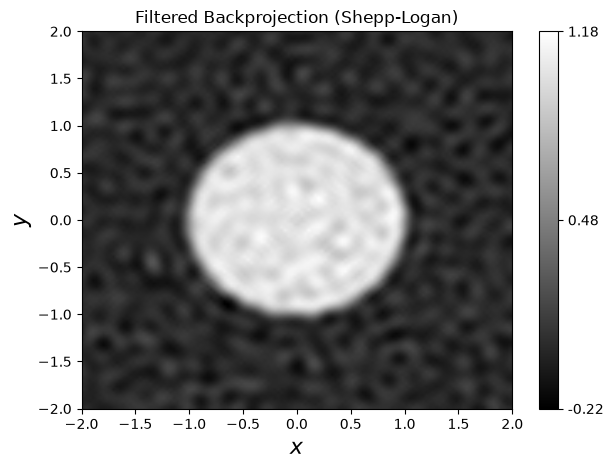

<Figure size 640x480 with 0 Axes>

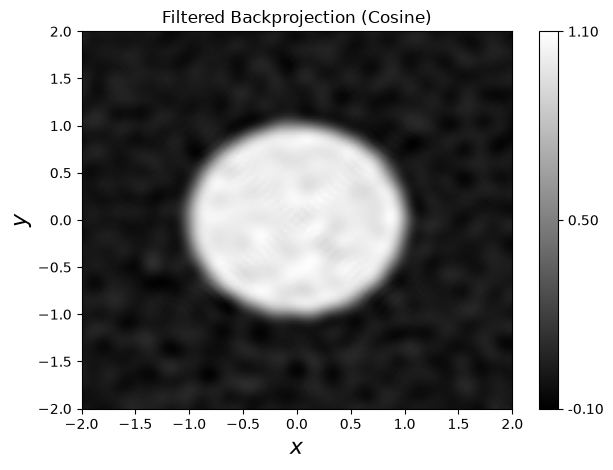

<Figure size 640x480 with 0 Axes>

In [37]:
# 9. Create a filtered backprojection operator and test different filter-types
frequency_scaling = 0.3

ram_lak = odl.applications.tomo.fbp_op(ray_transform, filter_type='Ram-Lak', frequency_scaling=frequency_scaling)
fig = ram_lak(noisy_sinogram).show(title='Filtered Backprojection (Ram-Lak)', cmap='gray')

shepp_logan = odl.applications.tomo.fbp_op(ray_transform, filter_type='Shepp-Logan', frequency_scaling=frequency_scaling)
fig = shepp_logan(noisy_sinogram).show(title='Filtered Backprojection (Shepp-Logan)', cmap='gray')

cosine = odl.applications.tomo.fbp_op(ray_transform, filter_type='Cosine', frequency_scaling=frequency_scaling)
fig = cosine(noisy_sinogram).show(title='Filtered Backprojection (Cosine)', cmap='gray')